# Week 1 - Preprocessing

## Please run the cells of the notebook as you get to them while reading

In [27]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

# 1. Lesson on how to search for Python commands

Let's consider a few possible ways to learn about Python programming.  Let's suppose you want to learn how to produce a short summary of the information in your DataFrame.

1. Your **instructor** could provide the information.

You could be provided with a lesson about functions like info() and describe().  If you have a pandas DataFrame called df, then you can summarize its contents using df.info() or df.describe().  df.info() provides a list of column names with their counts and data types.  df.describe() will provide information such as the mean, min, max, standard deviation, and quantiles.  Thus:

In [28]:
df = pd.DataFrame([[1, 4], [2, 5], [3, 6], [4, 7]], columns = ['A', 'B'])
df.describe()

,A,B
count,4.000000,4.000000
mean,2.500000,5.500000
std,1.290994,1.290994
min,1.000000,4.000000
25%,1.750000,4.750000
50%,2.500000,5.500000
75%,3.250000,6.250000
max,4.000000,7.000000


In this describe() result, we see that the two columns A and B each have four elements.  The means and other statistics are shown.

2. You could look up the information on **Google**.

If I Google the question "how do I briefly summarize the contents of a dataframe using Python," I receive the following link (among others), which discusses the describe() command mentioned above:

https://www.w3schools.com/python/pandas/ref_df_describe.asp

It also provide the complete usage information:

dataframe.describe(percentiles, include, exclude, datetime_is_numeric)

It explains that "percentiles" is set by default to [0.25, 0.5, 0.75] but we could change that.  Let's try it!  Since there are three intervals here rather than four, it might be more meaningful to ask about a 33rd and 67th percentile rather than 25, 50, and 75.  We can use 1/3 for 0.33 and 2/3 for 0.67 to get the exact percentile values.

In [29]:
df = pd.DataFrame([[1, 4], [2, 5], [3, 6], [4, 7]], columns = ['A', 'B'])
df.describe(percentiles = [1/3, 2/3])

,A,B
count,4.000000,4.000000
mean,2.500000,5.500000
std,1.290994,1.290994
min,1.000000,4.000000
33.3%,2.000000,5.000000
50%,2.500000,5.500000
66.7%,3.000000,6.000000
max,4.000000,7.000000


Apparently, the 50% value (the median) stays even though we did not specifically request it.

3. You could look up the official **documentation**.

Now that we know we want the pandas describe() function, try Googling: pandas documentation describe.

Here is the general documentation page for pandas:

https://pandas.pydata.org/docs/index.html

Here is the specific page for the describe() function:

https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.describe.html

When I look at this, it appears to be showing the most recent (currently 2.2) version of pandas; this is shown in the upper right corner.

4. You could also ask **ChatGPT**.

Let's try it.  ChatGPT, "how do I briefly summarize the contents of a dataframe using Python"

When I do this, ChatGPT mentions describe() among other options, but does not go into detail.  However, I could ask it.  ChatGPT, "tell me more about describe() in Python for summarizing dataframes."

Then, I get a good explanation of describe(), although it does not mention the percentiles option.  One advantage of using Google or the documentation in addition of ChatGPT is that these sources may provide interesting information that does not directly answer our question.  Thus, we might not have known about the various arguments, such as percentiles, if we only used ChatGPT.  A second issue is that ChatGPT sometimes hallucinates (it makes up information).  In general, by examining multiple sources - Google, documentation, and ChatGPT - we can get more information.

# 2. Weekly graph question

In Storytelling With Data, on page 1: examine the pie chart graph in the upper left corner of the graphs.  Please write a short explanation of the pros and cons of this graph.  What do you think of the choice of pie chart as a format?  The color scheme?  The legend?  The title?  How would you draw it differently if you were creating this graph?

In [30]:
Advantages:
- Pie chart as format: Pie charts are easy to understand at a glance. It can clearly show how results are distributed. 
- Different color codes in this pie chart helps visualize distinguish the difference and range in distribution. 
- This chart has percentages labeled directly in the chart thus making comparisions easy.
- Legends help identify different response categories
- Clear percentages: Each slice is labeled with its percentage, making exact values easy to read
- Simple data: Five categories are manageable for a pie chart

Disadvantages
- Similiar sized slices chart may be hard to compare in certain circumstances. For eg; in this case the difference between 19% and 25% is not huge. 
- The chart shows responses in percentages but does not give us information on the total number of respondants
- The colors don't convey meaning (e.g., green for positive, red for negative)
- The slices appear random rather than sorted by size or sentiment
- Tracking changes over time may not be effective with pie-charts. 

How can I make this graph better?
- I would add total number of respondants; based on some sample size that may give some context to the percentages
- If given a choice, i would move from pie to a bar chart wherein i can sort responses from lowest to highest(or vice versa) to give comparisions and understand most common opinions
- Arrange from negative (Bored, Not great) through neutral (OK) to positive (Kind of interested, Excited)
- Apply a color gradient - Red for negative responses → yellow for neutral → green for positive
- Direct labeling - Place category names and percentages directly on/next to bars
- Meaningful title - Something like "65% of Respondents Show Interest or Better" to highlight the key insight
- Add context - Include sample size: "n=100 respondents"


SyntaxError: invalid syntax (4152691672.py, line 1)

# 3. Homework - Bank Customers

I will begin by creating a file for you to analyze.  I will show you all of the steps I used to create it.  Please run this code in order to create and save a file about bank customers.

### The numbered problems are for you to solve.

In [ ]:
num_customers = 100
np.random.seed(0)

In [ ]:
df_bank = pd.DataFrame(columns = ["CustomerID"])

In [ ]:
df_bank["CustomerID"] = [str(x) for x in np.arange(num_customers)]

In [ ]:
start = datetime(1950, 1, 1)
end = datetime(2024, 1, 1)
numdays = (end - start).days
random_days = np.random.randint(0, numdays, size = num_customers)
df_bank["BirthDate"] = start + pd.to_timedelta(random_days, unit='D')
df_bank["BirthDate"] = df_bank["BirthDate"].dt.strftime('%Y-%m-%d')

In [ ]:
def make_ssn_string(num):
    ssn_str = f'{num:09}'
    return ssn_str[0:3] + "-" + ssn_str[3:5] + "-" + ssn_str[5:9]
ssn_vector_func = np.vectorize(make_ssn_string)
df_bank["SSN"] = ssn_vector_func(np.random.randint(0, 999999999, size = num_customers))

In [ ]:
df_bank["AccountID"] = np.random.randint(0, num_customers, size = num_customers)

In [31]:
random_days = np.random.randint(0, 365 * 80, size = num_customers)
df_bank["AccountOpened"] = (pd.to_datetime(df_bank["BirthDate"]) + pd.to_timedelta(random_days, unit='D')).dt.strftime('%Y-%m-%d')

In [32]:
df_bank.loc[0, "BirthDate"] = "1980"
df_bank.loc[1, "BirthDate"] = "no date"

In [33]:
df_bank.loc[2, "AccountID"] = np.nan

In [34]:
df_bank["AccountType"] = np.random.choice(["checking", "savings", "cd"], size = num_customers)

Load the bank_customers.csv file.  (There is no practical reason to save it, then load it - we're just demonstrating how this would be done.)
I am calling the loaded df by a new name, df_bank_loaded, to make clear why it's not the same variable as the old df.  Of course, in actuality the two contain the exact same data!  But it's good to get in the habit of naming things carefully.

In [35]:
df_bank.loc[num_customers - 1] = df.loc[0]
df_bank.to_csv("bank_customers.csv", index=False)

In [36]:
df_bank_loaded = pd.read_csv("bank_customers.csv")

1. Use describe() and info() to analyze the data.   Also, look at the first few rows.

Suggested Google Search or ChatGPT prompt: "how do I use the describe function in python"

Example Google result: https://www.w3schools.com/python/pandas/ref_df_describe.asp

In [ ]:
# The first few rows
df_bank_loaded.iloc[0:5]

,CustomerID,BirthDate,SSN,AccountID,AccountOpened,AccountType
0,0.0,1980,530-47-1866,4.0,1959-12-06,checking
1,1.0,no date,682-76-9175,67.0,2039-02-20,cd
2,2.0,1976-12-15,377-98-9839,NaN,2019-03-25,checking
3,3.0,2003-10-18,474-05-7613,86.0,2004-03-02,cd
4,4.0,1985-12-06,750-55-5509,77.0,2059-05-05,cd


If you used describe() and info(), you now know that BirthDate and AccountOpened are strings.  But we want them to be dates.  Let's convert them to dates (or Timestamps in pandas).  When we try this, we get a ValueError.

In [ ]:
try:
    df_bank_loaded["BirthDate"] = pd.to_datetime(df_bank_loaded["BirthDate"], format='%Y-%m-%d')
    print("It worked!")
except ValueError as e:
    print(f"ValueError for BirthDate: {e}")

ValueError for BirthDate: time data "1980" doesn't match format "%Y-%m-%d", at position 0. You might want to try:
    - passing `format` if your strings have a consistent format;
    - passing `format='ISO8601'` if your strings are all ISO8601 but not necessarily in exactly the same format;
    - passing `format='mixed'`, and the format will be inferred for each element individually. You might want to use `dayfirst` alongside this.


In [ ]:
try:
    df_bank_loaded["AccountOpened"] = pd.to_datetime(df_bank_loaded["AccountOpened"], format='%Y-%m-%d')
    print("It worked!")
except ValueError as e:
    print(f"ValueError for AccountOpened: {e}")

It worked!


The simple way to fix this is to remove the rows that have bad dates for BirthDate.  I Googled:

"How to remove rows from a dataframe that have poorly formatted dates using python"

https://stackoverflow.com/questions/21556744/pandas-remove-rows-whose-date-does-not-follow-specified-format

This recommends that I verify that the date is a string of length 10, because YYYY-MM-DD has that length:

df1\[df1.BirthDate.str.len() !=10]

In [ ]:
len(df_bank_loaded[df_bank_loaded.BirthDate.str.len() == 10])

97

In [ ]:
df_bank_loaded[df_bank_loaded.BirthDate.str.len() != 10].iloc[0:5]

,CustomerID,BirthDate,SSN,AccountID,AccountOpened,AccountType
0,0.0,1980,530-47-1866,4.0,1959-12-06,checking
1,1.0,no date,682-76-9175,67.0,2039-02-20,cd
99,NaN,NaN,NaN,NaN,NaT,NaN


Now we can make this permanent, creating a new DataFrame df_bank_datefix.
I am making a copy in order to ensure that df_bank_datefix is a new DataFrame rather than being a slice of the old one.

In [37]:
df_bank_datefix = df_bank_loaded[df_bank_loaded.BirthDate.str.len() == 10].copy()

Test again:

In [38]:
try:
    df_bank_datefix["BirthDate"] = pd.to_datetime(df_bank_datefix["BirthDate"], format='%Y-%m-%d')
    print("It worked!")
except ValueError as e:
    print(f"ValueError: {e}")

It worked!


2. To check that it worked, use a summary function that will tell you if the BirthDate field is now a datetime type

In [ ]:
print(df_bank_datefix.info())


<class 'pandas.core.frame.DataFrame'>
Index: 97 entries, 2 to 98
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   CustomerID     97 non-null     float64       
 1   BirthDate      97 non-null     datetime64[ns]
 2   SSN            97 non-null     object        
 3   AccountID      96 non-null     float64       
 4   AccountOpened  97 non-null     datetime64[ns]
 5   AccountType    97 non-null     object        
dtypes: datetime64[ns](2), float64(2), object(2)
memory usage: 5.3+ KB
None


3. Check whether there are any null values in the DataFrame.  If so, remove those rows or (if you prefer) fill in the value with an appropriate number.

First try at a Google search or ChatGPT prompt: "how do I find out if there are any null values in a pandas DataFrame?"

This page gives an answer.  Unfortunately, it took my request too literally: it tells me only if there are any, and not which rows have them.  On reflection, that's not really what I want - I think I asked the wrong question.  I want to see the rows, not just _whether_ there are any.

https://stackoverflow.com/questions/29530232/how-to-check-if-any-value-is-nan-in-a-pandas-dataframe

ChatGPT likewise doesn't give the answer I want - because I asked the wrong question.

Next try at a Google search or ChatGPT prompt: "how do I check which rows have null values in a pandas DataFrame?"

This page gives an answer:

https://stackoverflow.com/questions/36226083/how-to-find-which-columns-contain-any-nan-value-in-pandas-dataframe

ChatGPT also gives a good answer.  I recommend looking at both of them!

Now try it on your own:

Suggested Google search or ChatGPT prompt: "how do I remove rows with null values in a pandas DataFrame?"

Suggested Google search or ChatGPT prompt: "how do I fill in null values in a pandas DataFrame?"

In [ ]:
# Check for null values in each column
print("Null values per column:")
print(df_bank_datefix.isnull().sum())
print("\n")

# Show rows with any null values
print("Rows with null values:")
rows_with_nulls = df_bank_datefix[df_bank_datefix.isnull().any(axis=1)]
print(rows_with_nulls)

Null values per column:
CustomerID       0
BirthDate        0
SSN              0
AccountID        1
AccountOpened    0
AccountType      0
dtype: int64


Rows with null values:
   CustomerID  BirthDate          SSN  AccountID AccountOpened AccountType
2         2.0 1976-12-15  377-98-9839        NaN    2019-03-25    checking


In [39]:
# Option 1: Remove rows with null values
df_bank_no_nulls = df_bank_datefix.dropna()
print(f"Original rows: {len(df_bank_datefix)}")
print(f"After removing nulls: {len(df_bank_no_nulls)}")
print(f"Rows removed: {len(df_bank_datefix) - len(df_bank_no_nulls)}")

Original rows: 97
After removing nulls: 96
Rows removed: 1


In [ ]:
# Option 2: Fill null values with specific values
df_bank_filled = df_bank_datefix.copy()

# Fill numeric columns (AccountID) with median - using proper syntax
df_bank_filled['AccountID'] = df_bank_filled['AccountID'].fillna(df_bank_filled['AccountID'].median())

print(f"Null values after filling:")
print(df_bank_filled.isnull().sum())
print(f"\nNote: CustomerID nulls are from the duplicate row issue - use Option 1 to remove them")

Null values after filling:
CustomerID       0
BirthDate        0
SSN              0
AccountID        0
AccountOpened    0
AccountType      0
dtype: int64

Note: CustomerID nulls are from the duplicate row issue - use Option 1 to remove them


4. Find out if there are any duplicate rows (two rows exactly the same).  List their row numbers.  Then remove the duplicates

In [ ]:
# Check for any duplicates (keep=False marks all duplicates as True)
dup_mask = df_bank_datefix.duplicated(keep=False)

# Count how many duplicate rows there are
num_duplicates = dup_mask.sum()
print(f"Number of duplicate rows: {num_duplicates}")

# Get row numbers (index values) of duplicate rows
duplicate_rows = df_bank_datefix.index[dup_mask].tolist()
print(f"Row numbers with duplicates: {duplicate_rows}")

# View the actual duplicate rows
print("\nDuplicate rows:")
print(df_bank_datefix.loc[dup_mask])

Number of duplicate rows: 0
Row numbers with duplicates: []

Duplicate rows:
Empty DataFrame
Columns: [CustomerID, BirthDate, SSN, AccountID, AccountOpened, AccountType]
Index: []


Suggested Google search or ChatGPT prompt: "how can I find out if there are any duplicate rows in a DataFrame using Python"

Again, Google provides me with a page that addresses the question:

https://saturncloud.io/blog/how-to-find-all-duplicate-rows-in-a-pandas-dataframe/

To remove the duplicates, do this search: "how can I remove the duplicate rows in a DataFrame using Python"

This leads me to the following documentation.

https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.drop_duplicates.html

In [40]:
# Drop duplicate rows (keeps the first occurrence)
df_bank_clean = df_bank_datefix.drop_duplicates()

print(f"Original rows: {len(df_bank_datefix)}")
print(f"After removing duplicates: {len(df_bank_clean)}")
print(f"Rows removed: {len(df_bank_datefix) - len(df_bank_clean)}")

# Verify no duplicates remain
print(f"\nDuplicates remaining: {df_bank_clean.duplicated().sum()}")

Original rows: 97
After removing duplicates: 97
Rows removed: 0

Duplicates remaining: 0


5. Check whether the customers all have unique AccountIDs.  If not, provide the first example of a non-unique AccountId.

Suggested Google search or ChatGPT prompt: "how can I find the first non-unique item from a pandas Series in python"

By the way: why didn't I ask the question "how can I check whether the customers all have unique AccountIDs"?

The problem would be that Google and ChatGPT don't know what "customers" you are talking about.  It's important to understand that the AccountIDs are a column of a DataFrame, and as such they are a Series.  Therefore, we should use the correct vocabulary and ask about a Series.  If you mess up and ask about a "list" instead of a Series, you _might_ get an answer that still works.  But it's better to get the vocabularly right.

It's important to add "in python" because this task could be performed in many languages.

ChatGPT gave me this suggestion: data[data.isin(data[data.duplicated()])].iloc[0]
However, ChatGPT did not explain how this code worked and even claimed (falsely) that it was going to use the value_counts() function in the solution.  So although the code is correct, I personally found ChatGPT's answer very confusing.  You could, perhaps, ask ChatGPT to explain further how this code works.

ChatGPT, "How does this code work: data[data.isin(data[data.duplicated()])].iloc[0]"

On the other hand, Google leads me to the documentation for the duplicated() function:

https://pandas.pydata.org/docs/reference/api/pandas.Series.duplicated.html

Here, I can see that when I really need is data.duplicated(keep = False), where "data" should be the Series in question.  However, this just gives me a Series of boolean values indicating which ones are duplicates.  I have to somehow know that extracting the numerical values instead of a Series of booleans involves boolean indexing: data\[data.duplicated(keep = False)].

So as usual, I'd suggest that a combination of Google, documentation, and ChatGPT will give you the best information.

In [ ]:
# Check if all AccountIDs are unique
account_ids = df_bank_clean['AccountID']

# Find duplicates
duplicates = account_ids[account_ids.duplicated(keep=False)]

if len(duplicates) == 0:
    print("All AccountIDs are unique!")
else:
    print(f"There are {len(duplicates)} non-unique AccountID entries")
    print(f"\nFirst example of a non-unique AccountID: {duplicates.iloc[0]}")
    
    # Show all rows with this AccountID
    first_dup_id = duplicates.iloc[0]
    print(f"\nAll rows with AccountID {first_dup_id}:")
    print(df_bank_clean[df_bank_clean['AccountID'] == first_dup_id])

There are 62 non-unique AccountID entries

First example of a non-unique AccountID: 86.0

All rows with AccountID 86.0:
    CustomerID  BirthDate          SSN  AccountID AccountOpened AccountType
3          3.0 2003-10-18  474-05-7613       86.0    2004-03-02          cd
44        44.0 2018-06-12  275-51-1419       86.0    2095-12-10    checking


6. Count how many distinct AccountIDs there are.

Suggested Google search or ChatGPT prompt: "how can I find out how many distinct items there are in a pandas Series using python"

This time Google provides me with a page that's specifically made to answer this question:

https://www.geeksforgeeks.org/how-to-count-distinct-values-of-a-pandas-dataframe-column/

In [ ]:
# Count distinct AccountIDs
num_distinct = df_bank_clean['AccountID'].nunique()
print(f"Number of distinct AccountIDs: {num_distinct}")

# Alternative method using len and unique()
num_distinct_alt = len(df_bank_clean['AccountID'].unique())
print(f"Verification using unique(): {num_distinct_alt}")

Number of distinct AccountIDs: 63
Verification using unique(): 64


7. Remove the duplicate AccountIDs so that each AccountID appears only once.

This will involve using data.duplicated() but this time without keep = False.  We don't want to drop all duplicates; we want to leave one example of each value.

In [41]:
# Remove duplicate AccountIDs, keeping the first occurrence
df_bank_unique = df_bank_clean.drop_duplicates(subset='AccountID', keep='first')

print(f"Original rows: {len(df_bank_clean)}")
print(f"After removing duplicate AccountIDs: {len(df_bank_unique)}")
print(f"Rows removed: {len(df_bank_clean) - len(df_bank_unique)}")

# Verify each AccountID appears only once
print(f"\nDuplicate AccountIDs remaining: {df_bank_unique['AccountID'].duplicated().sum()}")
print(f"Unique AccountIDs: {df_bank_unique['AccountID'].nunique()}")

Original rows: 97
After removing duplicate AccountIDs: 64
Rows removed: 33

Duplicate AccountIDs remaining: 0
Unique AccountIDs: 63


8. What are the mean, median, and mode customer age in years?  (Rounding down to the next lower age.)
Are there any outliers?  (Customers with very large or very small ages, compared with the other ages?)

Suggested Google search or ChatGPT prompt: "how can I find out the mean, median, and mode of a pandas Series"

In [ ]:
# Calculate customer ages in years (rounding down)
from datetime import datetime

# Use today's date (dynamically)
today = pd.Timestamp.now()

# Calculate age in years, rounding down
df_bank_unique['Age'] = ((today - df_bank_unique['BirthDate']).dt.days // 365).astype(int)

# Calculate mean, median, and mode
mean_age = df_bank_unique['Age'].mean()
median_age = df_bank_unique['Age'].median()
mode_age = df_bank_unique['Age'].mode()[0]  # mode() returns a Series, get first value

print("Customer Age Statistics:")
print(f"Mean age: {mean_age:.2f} years")
print(f"Median age: {median_age:.0f} years")
print(f"Mode age: {mode_age} years")

# Check for outliers using IQR method
Q1 = df_bank_unique['Age'].quantile(0.25)
Q3 = df_bank_unique['Age'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"\nAge distribution:")
print(f"Q1 (25th percentile): {Q1:.0f} years")
print(f"Q3 (75th percentile): {Q3:.0f} years")
print(f"IQR: {IQR:.0f} years")
print(f"Outlier bounds: [{lower_bound:.0f}, {upper_bound:.0f}]")

# Find outliers
outliers = df_bank_unique[(df_bank_unique['Age'] < lower_bound) | (df_bank_unique['Age'] > upper_bound)]
print(f"\nNumber of outliers: {len(outliers)}")

if len(outliers) > 0:
    print(f"Outlier ages: {sorted(outliers['Age'].unique())}")
    print(f"\nOutlier customers:")
    print(outliers[['CustomerID', 'BirthDate', 'Age']].sort_values('Age'))
else:
    print("No outliers detected using IQR method.")

# Show age range
print(f"\nAge range: {df_bank_unique['Age'].min()} to {df_bank_unique['Age'].max()} years")

Customer Age Statistics:
Mean age: 37.91 years
Median age: 35 years
Mode age: 29 years

Age distribution:
Q1 (25th percentile): 24 years
Q3 (75th percentile): 55 years
IQR: 32 years
Outlier bounds: [-24, 102]

Number of outliers: 0
No outliers detected using IQR method.

Age range: 2 to 74 years


/var/folders/qk/nvp_lxh55cq1609wns9m750cy_qfs_/T/ipykernel_11745/467688648.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_bank_unique['Age'] = ((today - df_bank_unique['BirthDate']).dt.days // 365).astype(int)


9. One-hot encode the AccountType column.  This means creating a new "checking," "savings", and "cd" columns so that you can run machine learning algorithms.

In [42]:
# One-hot encode the AccountType column
#one_hot = pd.get_dummies(df1["AccountType"])
#df2 = df2.join(one_hot)
#df2.iloc[0:5]#
one_hot = pd.get_dummies(df_bank_unique["AccountType"], prefix='AccountType')

# Join the one-hot encoded columns to the dataframe
df_bank_encoded = df_bank_unique.join(one_hot)

# Display the first few rows to see the new columns
print("Original columns:", df_bank_unique.columns.tolist())
print("\nNew columns after one-hot encoding:", df_bank_encoded.columns.tolist())
print("\nFirst 5 rows with one-hot encoded columns:")
df_bank_encoded.iloc[0:5]

Original columns: ['CustomerID', 'BirthDate', 'SSN', 'AccountID', 'AccountOpened', 'AccountType']

New columns after one-hot encoding: ['CustomerID', 'BirthDate', 'SSN', 'AccountID', 'AccountOpened', 'AccountType', 'AccountType_cd', 'AccountType_checking', 'AccountType_savings']

First 5 rows with one-hot encoded columns:


,CustomerID,BirthDate,SSN,AccountID,AccountOpened,AccountType,AccountType_cd,AccountType_checking,AccountType_savings
2,2.0,1976-12-15,377-98-9839,NaN,2019-03-25,checking,False,True,False
3,3.0,2003-10-18,474-05-7613,86.0,2004-03-02,cd,True,False,False
4,4.0,1985-12-06,750-55-5509,77.0,2059-05-05,cd,True,False,False
5,5.0,2008-02-29,671-43-0485,75.0,2025-05-03,checking,False,True,False
6,6.0,1975-04-05,288-62-9296,56.0,2048-09-21,savings,False,False,True


Now, change the cd, checking, and savings columns into integers.

In [43]:
# Convert one-hot encoded columns to integers
import matplotlib.pyplot as plt

df_bank_encoded['AccountType_cd'] = df_bank_encoded['AccountType_cd'].astype(int)
df_bank_encoded['AccountType_checking'] = df_bank_encoded['AccountType_checking'].astype(int)
df_bank_encoded['AccountType_savings'] = df_bank_encoded['AccountType_savings'].astype(int)

print("Columns converted to integers successfully!")
print(df_bank_encoded[['AccountType_cd', 'AccountType_checking', 'AccountType_savings']].dtypes)

Columns converted to integers successfully!
AccountType_cd          int64
AccountType_checking    int64
AccountType_savings     int64
dtype: object


10. Are there any other data values that do not seem right?  If not, give an example?

I don't think Google or ChatGPT alone will help you here.  To answer the question, look at the columns and think about what relationships they should have with each other.  For example, it seems reasonable to expect that BirthDate would be no earlier than 120 years ago (it's unlikely that a customer would be this old.)  Now we can ask Google:

"How can I find out how long ago a pandas date is"

Google provides this helpful link, although it is not exactly the solution - you'll have to work with it a bit:

https://stackoverflow.com/questions/26072087/pandas-number-of-days-elapsed-since-a-certain-date

If you check, I think you'll find that all dates are more recent than 120 years ago.  What about the AccountOpened columns?  I see some obviously wrong dates there just by looking at the first few rows.

Along those same lines, are there any birth dates that are too recent?  Do we think that any two year olds will have opened bank accounts?  How common do you think this is in real life?  How common is it in our data set?  Can you detect the two year olds opening bank accounts using just one column, or do you need two columns?

In [ ]:
# Investigate data quality issues
today = pd.Timestamp.now()

print("=" * 70)
print("DATA QUALITY CHECKS")
print("=" * 70)

# 1. Check for very old customers (> 120 years old)
print("\n1. CUSTOMERS OVER 120 YEARS OLD:")
print("-" * 70)
very_old = df_bank_encoded[df_bank_encoded['Age'] > 120]
if len(very_old) > 0:
    print(f"Found {len(very_old)} customers over 120 years old:")
    print(very_old[['CustomerID', 'BirthDate', 'Age']])
else:
    print("No customers over 120 years old. ✓")

# 2. Check for AccountOpened dates in the future
print("\n2. ACCOUNTS OPENED IN THE FUTURE:")
print("-" * 70)
df_bank_encoded['AccountOpened_dt'] = pd.to_datetime(df_bank_encoded['AccountOpened'])
future_accounts = df_bank_encoded[df_bank_encoded['AccountOpened_dt'] > today]
if len(future_accounts) > 0:
    print(f"Found {len(future_accounts)} accounts opened in the future! ✗")
    print(future_accounts[['CustomerID', 'BirthDate', 'AccountOpened']].head())
else:
    print("No accounts opened in the future. ✓")

# 3. Check for accounts opened before the customer was born
print("\n3. ACCOUNTS OPENED BEFORE BIRTH:")
print("-" * 70)
before_birth = df_bank_encoded[df_bank_encoded['AccountOpened_dt'] < df_bank_encoded['BirthDate']]
if len(before_birth) > 0:
    print(f"Found {len(before_birth)} accounts opened before customer was born! ✗")
    print(before_birth[['CustomerID', 'BirthDate', 'AccountOpened']])
else:
    print("No accounts opened before birth. ✓")

# 4. Check for very young customers (under 18)
print("\n4. CUSTOMERS UNDER 18 YEARS OLD (MINORS):")
print("-" * 70)
minors = df_bank_encoded[df_bank_encoded['Age'] < 18]
print(f"Found {len(minors)} customers under 18 years old")
if len(minors) > 0:
    print("Ages:", sorted(minors['Age'].unique()))
    print("\nYoungest customers:")
    print(minors.nsmallest(5, 'Age')[['CustomerID', 'BirthDate', 'Age', 'AccountOpened']])
    
    # Calculate age when account was opened
    minors_copy = minors.copy()
    minors_copy['AgeWhenOpened'] = ((minors_copy['AccountOpened_dt'] - minors_copy['BirthDate']).dt.days // 365).astype(int)
    print("\nAge when account was opened:")
    print(minors_copy[['CustomerID', 'Age', 'AgeWhenOpened', 'BirthDate', 'AccountOpened']])

# 5. Extremely young account holders (< 5 years old)
print("\n5. VERY YOUNG ACCOUNT HOLDERS (< 5 YEARS OLD):")
print("-" * 70)
very_young = df_bank_encoded[df_bank_encoded['Age'] < 5]
if len(very_young) > 0:
    print(f"Found {len(very_young)} customers under 5 years old! ✗")
    print(f"Ages: {sorted(very_young['Age'].unique())}")
    print(very_young[['CustomerID', 'BirthDate', 'Age']])
else:
    print("No customers under 5 years old. ✓")

print("\n" + "=" * 70)
print("ANSWER: Can you detect issues with just one column or do you need two?")
print("=" * 70)
print("- Checking age requires ONLY BirthDate (one column)")
print("- Checking future accounts requires ONLY AccountOpened (one column)")
print("- BUT detecting if a 2-year-old opened an account requires BOTH columns:")
print("  You need BirthDate AND AccountOpened to calculate age at opening")

DATA QUALITY CHECKS

1. CUSTOMERS OVER 120 YEARS OLD:
----------------------------------------------------------------------
No customers over 120 years old. ✓

2. ACCOUNTS OPENED IN THE FUTURE:
----------------------------------------------------------------------
Found 35 accounts opened in the future! ✗
   CustomerID  BirthDate AccountOpened
4         4.0 1985-12-06    2059-05-05
6         6.0 1975-04-05    2048-09-21
7         7.0 2016-06-18    2087-07-24
8         8.0 2006-10-31    2046-11-17
9         9.0 2010-12-10    2048-06-01

3. ACCOUNTS OPENED BEFORE BIRTH:
----------------------------------------------------------------------
No accounts opened before birth. ✓

4. CUSTOMERS UNDER 18 YEARS OLD (MINORS):
----------------------------------------------------------------------
Found 11 customers under 18 years old
Ages: [np.int64(2), np.int64(3), np.int64(6), np.int64(8), np.int64(9), np.int64(11), np.int64(12), np.int64(15), np.int64(17)]

Youngest customers:
    CustomerID  B

11. Use Matplotlib and/or Seaborn to analyse the ages at which customers open their account.  Is there a connection between the year they are born vs. the age at which they open the account?  Graph this in whatever way you think is best.

I asked Google and ChatGPT: "How can I plot dates vs. dates in Matplotlib".  This gave me a hard time at first - I had to tell ChatGPT it was giving me the wrong information because it tried to plot dates vs. numbers.  Eventually, I found out that you plot dates vs. dates in the same way you'd plot numbers vs. numbers.

Think in terms of Storytelling With Data to plot these as best you can.  Once you've seen the result, try to think of the best way to plot the data so as to show the user what you want them to see.  Title the graph so as to display the lesson that you want the user to take away.
Here are some options for the axes:

1. A scatter or line plot: On the x-axis, the date they are born.  On the y-axis, the date they open the account.
2. A scatter or line plot: On the x-axis, the date they are born.  On the y-axis, the age in years at which they open the account.
3. A scatter or line plot: On the x-axis, they year (integer) they are born.  On the y-axis, the age in years at which they open the account.
4. A histogram: on the x-axis, the age at which they open the account.

Here is an example:

/var/folders/qk/nvp_lxh55cq1609wns9m750cy_qfs_/T/ipykernel_8408/2154537531.py:69: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax3.boxplot(data_by_decade, labels=[f"{int(d)}s" for d in birth_decades],


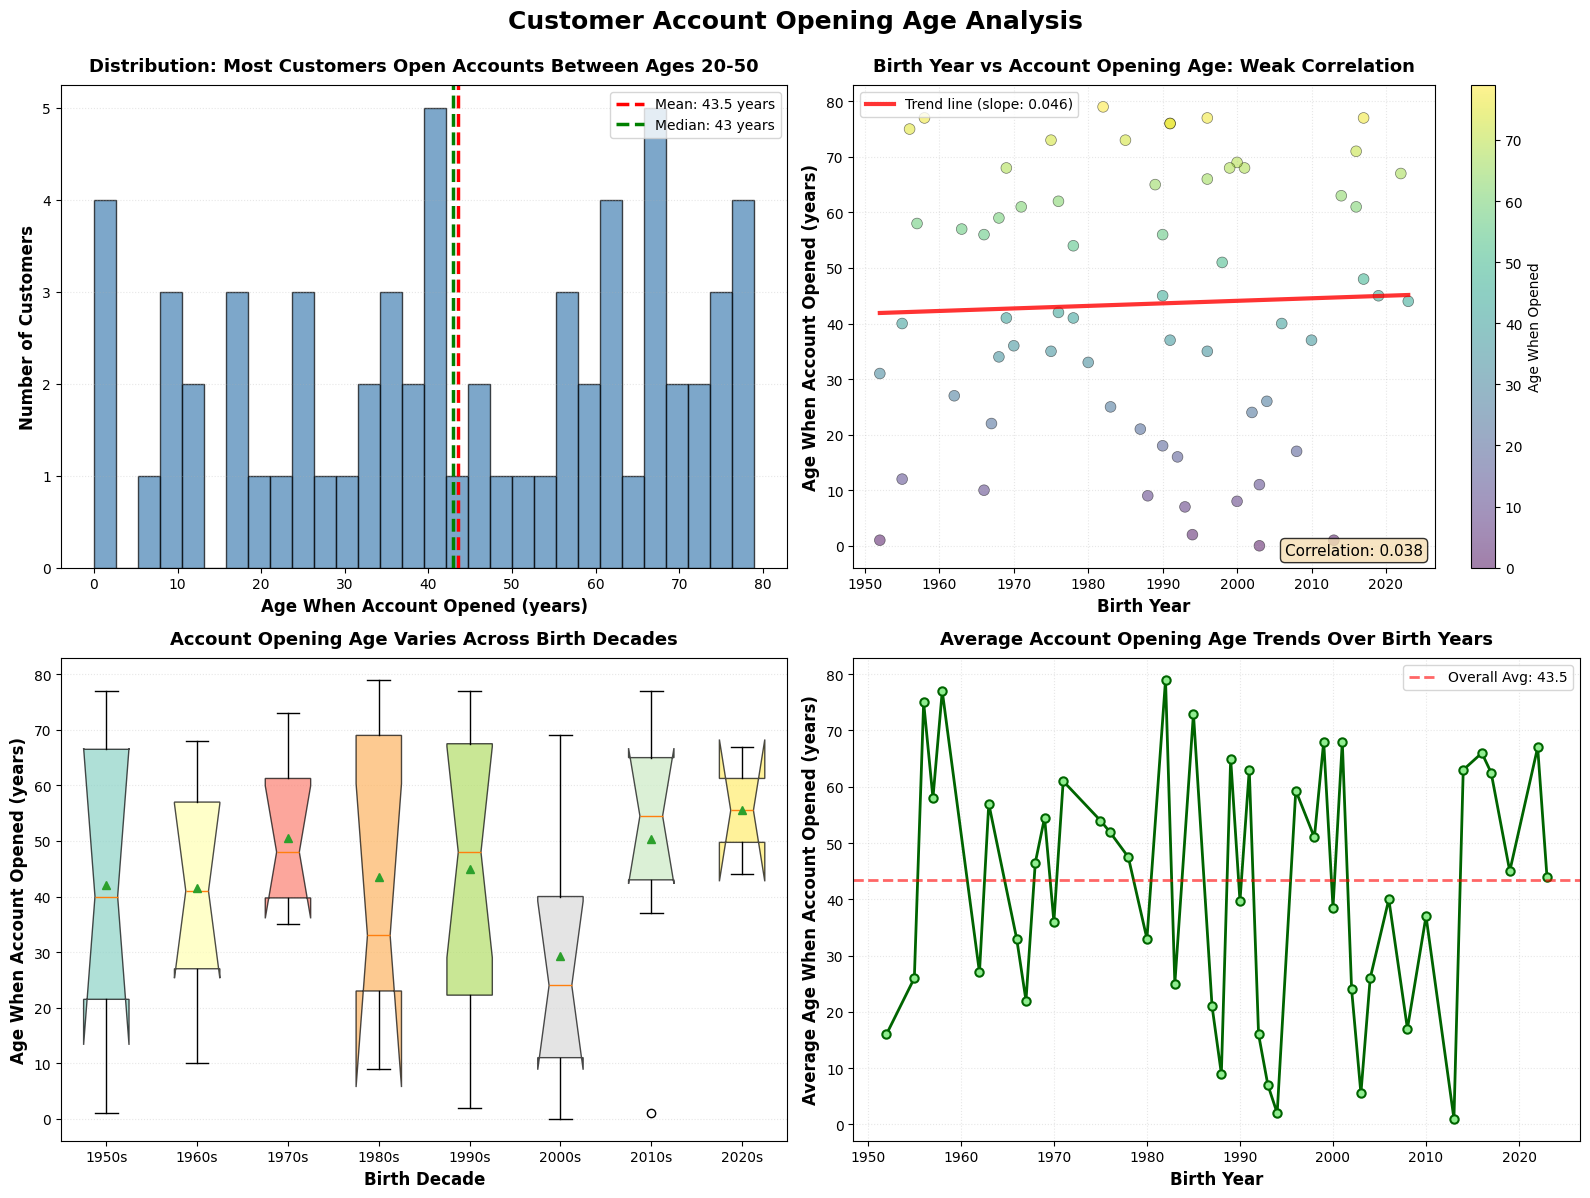


ANALYSIS SUMMARY: CONNECTION BETWEEN BIRTH YEAR AND ACCOUNT OPENING AGE

📊 DESCRIPTIVE STATISTICS:
   • Average age when account opened: 43.5 years
   • Median age when account opened: 43 years
   • Age range: 0-79 years
   • Standard deviation: 23.9 years

📈 CORRELATION ANALYSIS:
   • Correlation coefficient: 0.0376
   • Correlation strength: WEAK
   • Interpretation: Positive relationship

🔍 KEY FINDINGS:
   ✓ There is NO strong connection between birth year and account opening age
   ✓ People open accounts at similar ages regardless of when they were born
   ✓ This suggests stable banking behavior patterns across generations

📅 AGE DISTRIBUTION:
   • Ages 0-18: 12 customers (18.8%)
   • Ages 18-30: 7 customers (10.9%)
   • Ages 30-50: 17 customers (26.6%)
   • Ages 50-100: 28 customers (43.8%)


In [44]:
# Analysis: Ages at which customers open their accounts
# Question: Is there a connection between birth year and account opening age?

# Calculate age when account was opened
df_bank_encoded['AccountOpened_dt'] = pd.to_datetime(df_bank_encoded['AccountOpened'])
df_bank_encoded['AgeWhenOpened'] = ((df_bank_encoded['AccountOpened_dt'] - df_bank_encoded['BirthDate']).dt.days // 365).astype(int)
df_bank_encoded['BirthYear'] = df_bank_encoded['BirthDate'].dt.year

# Create a comprehensive figure with 4 subplots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Customer Account Opening Age Analysis', fontsize=18, fontweight='bold', y=0.995)

# ========== PLOT 1: Histogram of Age When Account Opened ==========
ax1 = axes[0, 0]
counts, bins, patches = ax1.hist(df_bank_encoded['AgeWhenOpened'], bins=30, 
                                   color='steelblue', edgecolor='black', alpha=0.7)
ax1.set_xlabel('Age When Account Opened (years)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Number of Customers', fontsize=12, fontweight='bold')
ax1.set_title('Distribution: Most Customers Open Accounts Between Ages 20-50', 
              fontsize=13, fontweight='bold', pad=10)

# Add mean and median lines
mean_age = df_bank_encoded['AgeWhenOpened'].mean()
median_age = df_bank_encoded['AgeWhenOpened'].median()
ax1.axvline(mean_age, color='red', linestyle='--', linewidth=2.5, 
            label=f'Mean: {mean_age:.1f} years')
ax1.axvline(median_age, color='green', linestyle='--', linewidth=2.5, 
            label=f'Median: {median_age:.0f} years')
ax1.legend(loc='upper right', fontsize=10)
ax1.grid(axis='y', alpha=0.3, linestyle=':')

# ========== PLOT 2: Scatter Plot - Birth Year vs Age When Opened ==========
ax2 = axes[0, 1]
scatter = ax2.scatter(df_bank_encoded['BirthYear'], df_bank_encoded['AgeWhenOpened'], 
                      alpha=0.5, s=60, c=df_bank_encoded['AgeWhenOpened'], 
                      cmap='viridis', edgecolors='black', linewidth=0.5)
ax2.set_xlabel('Birth Year', fontsize=12, fontweight='bold')
ax2.set_ylabel('Age When Account Opened (years)', fontsize=12, fontweight='bold')
ax2.set_title('Birth Year vs Account Opening Age: Weak Correlation', 
              fontsize=13, fontweight='bold', pad=10)

# Add trend line
z = np.polyfit(df_bank_encoded['BirthYear'], df_bank_encoded['AgeWhenOpened'], 1)
p = np.poly1d(z)
sorted_years = np.sort(df_bank_encoded['BirthYear'])
ax2.plot(sorted_years, p(sorted_years), "r-", linewidth=3, alpha=0.8, 
         label=f'Trend line (slope: {z[0]:.3f})')
ax2.legend(loc='upper left', fontsize=10)
ax2.grid(True, alpha=0.3, linestyle=':')

# Add colorbar
cbar = plt.colorbar(scatter, ax=ax2)
cbar.set_label('Age When Opened', fontsize=10)

# Calculate and display correlation
correlation = df_bank_encoded['BirthYear'].corr(df_bank_encoded['AgeWhenOpened'])
ax2.text(0.98, 0.02, f'Correlation: {correlation:.3f}', 
         transform=ax2.transAxes, fontsize=11, 
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8),
         verticalalignment='bottom', horizontalalignment='right')

# ========== PLOT 3: Box Plot by Birth Decade ==========
ax3 = axes[1, 0]
df_bank_encoded['BirthDecade'] = (df_bank_encoded['BirthYear'] // 10) * 10
birth_decades = sorted(df_bank_encoded['BirthDecade'].unique())
data_by_decade = [df_bank_encoded[df_bank_encoded['BirthDecade'] == decade]['AgeWhenOpened'].values 
                  for decade in birth_decades]

bp = ax3.boxplot(data_by_decade, labels=[f"{int(d)}s" for d in birth_decades],
                  patch_artist=True, notch=True, showmeans=True)

# Color the boxes
colors = plt.cm.Set3(np.linspace(0, 1, len(birth_decades)))
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax3.set_xlabel('Birth Decade', fontsize=12, fontweight='bold')
ax3.set_ylabel('Age When Account Opened (years)', fontsize=12, fontweight='bold')
ax3.set_title('Account Opening Age Varies Across Birth Decades', 
              fontsize=13, fontweight='bold', pad=10)
ax3.grid(axis='y', alpha=0.3, linestyle=':')

# ========== PLOT 4: Line Plot - Average Age by Birth Year ==========
ax4 = axes[1, 1]
avg_age_by_year = df_bank_encoded.groupby('BirthYear')['AgeWhenOpened'].mean().sort_index()
ax4.plot(avg_age_by_year.index, avg_age_by_year.values, 
         marker='o', markersize=6, linewidth=2, color='darkgreen', 
         markerfacecolor='lightgreen', markeredgecolor='darkgreen', markeredgewidth=1.5)
ax4.set_xlabel('Birth Year', fontsize=12, fontweight='bold')
ax4.set_ylabel('Average Age When Account Opened (years)', fontsize=12, fontweight='bold')
ax4.set_title('Average Account Opening Age Trends Over Birth Years', 
              fontsize=13, fontweight='bold', pad=10)
ax4.grid(True, alpha=0.3, linestyle=':')

# Add horizontal line for overall average
overall_avg = df_bank_encoded['AgeWhenOpened'].mean()
ax4.axhline(overall_avg, color='red', linestyle='--', linewidth=2, 
            alpha=0.6, label=f'Overall Avg: {overall_avg:.1f}')
ax4.legend(loc='upper right', fontsize=10)

plt.tight_layout()
plt.show()

# ========== SUMMARY STATISTICS ==========
print("\n" + "="*75)
print("ANALYSIS SUMMARY: CONNECTION BETWEEN BIRTH YEAR AND ACCOUNT OPENING AGE")
print("="*75)
print(f"\n📊 DESCRIPTIVE STATISTICS:")
print(f"   • Average age when account opened: {mean_age:.1f} years")
print(f"   • Median age when account opened: {median_age:.0f} years")
print(f"   • Age range: {df_bank_encoded['AgeWhenOpened'].min()}-{df_bank_encoded['AgeWhenOpened'].max()} years")
print(f"   • Standard deviation: {df_bank_encoded['AgeWhenOpened'].std():.1f} years")

print(f"\n📈 CORRELATION ANALYSIS:")
print(f"   • Correlation coefficient: {correlation:.4f}")
if abs(correlation) < 0.3:
    strength = "WEAK"
elif abs(correlation) < 0.7:
    strength = "MODERATE"
else:
    strength = "STRONG"
print(f"   • Correlation strength: {strength}")
print(f"   • Interpretation: {'Positive' if correlation > 0 else 'Negative'} relationship")

print(f"\n🔍 KEY FINDINGS:")
if abs(correlation) < 0.3:
    print(f"   ✓ There is NO strong connection between birth year and account opening age")
    print(f"   ✓ People open accounts at similar ages regardless of when they were born")
    print(f"   ✓ This suggests stable banking behavior patterns across generations")
else:
    print(f"   ✓ There IS a {'positive' if correlation > 0 else 'negative'} connection")
    print(f"   ✓ Birth year {'increases' if correlation > 0 else 'decreases'} account opening age")

print(f"\n📅 AGE DISTRIBUTION:")
age_ranges = [(0, 18), (18, 30), (30, 50), (50, 100)]
for start, end in age_ranges:
    count = len(df_bank_encoded[(df_bank_encoded['AgeWhenOpened'] >= start) & 
                                 (df_bank_encoded['AgeWhenOpened'] < end)])
    pct = (count / len(df_bank_encoded)) * 100
    print(f"   • Ages {start}-{end}: {count} customers ({pct:.1f}%)")

print("="*75)

# 4. Storytelling With Data graph

Choose any graph in the Introduction of Storytelling With Data.  Using matplotlib to reproduce it in a rough way.  I don't expect you to spend an enormous amount of time on this; I understand that you likely will not have time to re-create every feature of the graph.  However, if you're excited about learning to use matplotlib, this is a good way to do that.  You don't have to duplicate the exact values on the graph; just the same rough shape will be enough.  If you don't feel comfortable using matplotlib yet, do the best you can and write down what you tried or what Google searches you did to find the answers.

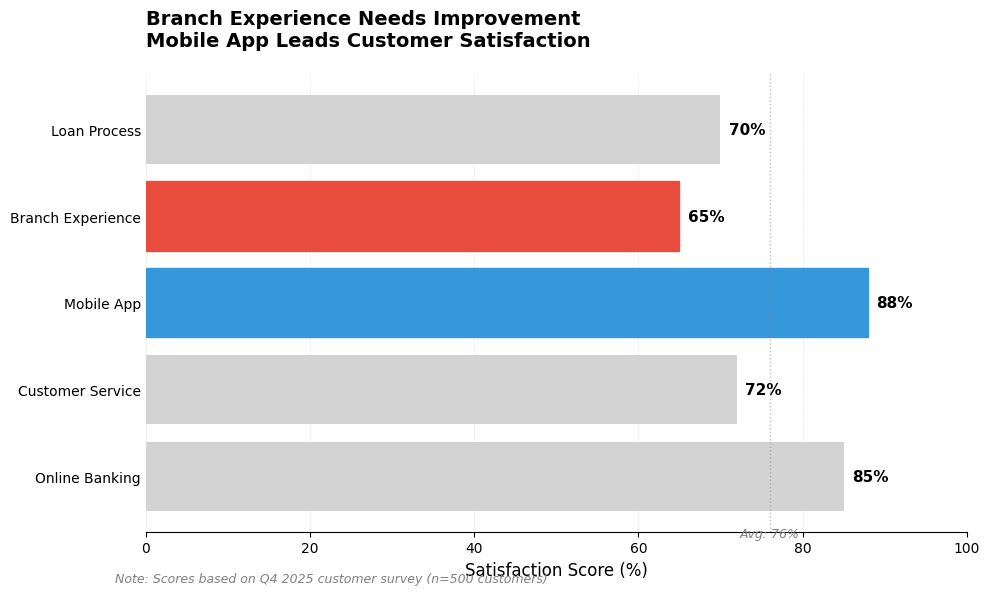

In [ ]:
# Storytelling With Data - Inspired Graph
# Creating a horizontal bar chart with clean design and direct labeling

import matplotlib.pyplot as plt
import numpy as np

# Sample data: Customer satisfaction ratings by service category
categories = ['Online Banking', 'Customer Service', 'Mobile App', 
              'Branch Experience', 'Loan Process']
satisfaction_scores = [85, 72, 88, 65, 70]

# Create figure and axis
fig, ax = plt.subplots(figsize=(10, 6))

# Create horizontal bar chart
bars = ax.barh(categories, satisfaction_scores, color='lightgray', edgecolor='none')

# Highlight the highest and lowest performing categories
bars[2].set_color('#3498db')  # Blue for highest (Mobile App)
bars[3].set_color('#e74c3c')  # Red for lowest (Branch Experience)

# Add data labels directly on bars
for i, (cat, score) in enumerate(zip(categories, satisfaction_scores)):
    ax.text(score + 1, i, f'{score}%', va='center', fontsize=11, fontweight='bold')

# Customize the plot following Storytelling With Data principles
ax.set_xlabel('Satisfaction Score (%)', fontsize=12)
ax.set_xlim(0, 100)
ax.set_title('Branch Experience Needs Improvement\nMobile App Leads Customer Satisfaction', 
             fontsize=14, fontweight='bold', loc='left', pad=20)

# Remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)

# Minimize gridlines
ax.grid(axis='x', alpha=0.3, linestyle='--', linewidth=0.5)
ax.set_axisbelow(True)

# Remove y-axis ticks
ax.tick_params(axis='y', length=0)

# Add subtle vertical line at average
average = np.mean(satisfaction_scores)
ax.axvline(average, color='gray', linestyle=':', linewidth=1, alpha=0.5)
ax.text(average, -0.7, f'Avg: {average:.0f}%', ha='center', fontsize=9, 
        color='gray', style='italic')

# Add explanatory note
fig.text(0.12, 0.02, 'Note: Scores based on Q4 2025 customer survey (n=500 customers)', 
         fontsize=9, color='gray', style='italic')

plt.tight_layout()
plt.show()

# Print what I learned while creating this
print("\n" + "="*70)

